In [75]:
# Import Required Libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Image Blender - Overlay Images with Masking

## Overview
This notebook implements an image blending system that overlays a smaller image (foreground) onto a larger image (background) using mask-based blending. 

## Features
- Automatic mask generation from grayscale conversion
- Precise image alignment with offsets
- Seamless blending using bitwise operations
- Support for any image size and position

## Workflow
1. Load source images (background and foreground)
2. Create inverted mask from foreground
3. Extract background and foreground regions
4. Blend using mask-based bitwise operations
5. Compose final result

## Helper Functions

Define modular functions for image blending operations

In [76]:
def load_images(bg_path, fg_path):
    """
    Load and convert background and foreground images to RGB.
    
    Args:
        bg_path (str): Path to background image
        fg_path (str): Path to foreground image
    
    Returns:
        tuple: (bg_image, fg_image) in RGB format
    """
    bg_img = cv2.imread(bg_path)
    fg_img = cv2.imread(fg_path)
    bg_img = cv2.cvtColor(bg_img, cv2.COLOR_BGR2RGB)
    fg_img = cv2.cvtColor(fg_img, cv2.COLOR_BGR2RGB)
    return bg_img, fg_img


def create_mask(fg_image):
    """
    Create an inverted binary mask from foreground image.
    White regions (255) = keep, Black regions (0) = transparent.
    
    Args:
        fg_image (np.ndarray): Foreground image in RGB format
    
    Returns:
        np.ndarray: Inverted binary mask
    """
    # Convert to grayscale
    fg_gray = cv2.cvtColor(fg_image, cv2.COLOR_RGB2GRAY)
    # Invert the mask
    mask_inv = cv2.bitwise_not(fg_gray)
    return mask_inv, fg_gray


def extract_regions(bg_roi, fg_image, mask_inv, roi_shape):
    """
    Extract background and foreground regions using masks.
    
    Args:
        bg_roi (np.ndarray): Background ROI to overlay on
        fg_image (np.ndarray): Foreground image
        mask_inv (np.ndarray): Inverted mask
        roi_shape (tuple): Target shape (height, width)
    
    Returns:
        tuple: (background_region, foreground_region)
    """
    # Resize foreground and mask to match ROI dimensions
    fg_resized = cv2.resize(fg_image, (roi_shape[1], roi_shape[0]))
    mask_inv_resized = cv2.resize(mask_inv, (roi_shape[1], roi_shape[0]))
    
    # Extract background (keep regions where mask_inv is white/255)
    bk_roi = cv2.bitwise_and(bg_roi, bg_roi, mask=mask_inv_resized)
    
    # Extract foreground (keep regions where mask_inv is black/0)
    fg_roi = cv2.bitwise_and(fg_resized, fg_resized, mask=cv2.bitwise_not(mask_inv_resized))
    
    return bk_roi, fg_roi


def blend_images(bg_roi, fg_image, mask_inv, y_offset, x_offset, bg_image):
    """
    Blend foreground image onto background image at specified offsets.
    
    Args:
        bg_roi (np.ndarray): Background ROI
        fg_image (np.ndarray): Foreground image
        mask_inv (np.ndarray): Inverted mask
        y_offset (int): Y-axis offset for blending
        x_offset (int): X-axis offset for blending
        bg_image (np.ndarray): Full background image
    
    Returns:
        np.ndarray: Final blended image
    """
    # Calculate ROI dimensions
    roi_height = bg_image.shape[0] - y_offset
    roi_width = bg_image.shape[1] - x_offset
    roi_shape = (roi_height, roi_width)
    
    # Extract regions
    bk_roi, fg_roi = extract_regions(bg_roi, fg_image, mask_inv, roi_shape)
    
    # Blend background and foreground
    final_roi = cv2.add(bk_roi, fg_roi)
    
    # Compose final result
    result = bg_image.copy()
    result[y_offset:y_offset+final_roi.shape[0], x_offset:x_offset+final_roi.shape[1]] = final_roi
    
    return result, final_roi


def blend_and_display(bg_path, fg_path, y_offset, x_offset, figsize=(12, 8)):
    """
    Complete image blending pipeline: load, process, blend, and display.
    
    Args:
        bg_path (str): Path to background image
        fg_path (str): Path to foreground image
        y_offset (int): Y-axis offset for overlay placement
        x_offset (int): X-axis offset for overlay placement
        figsize (tuple): Figure size for display
    
    Returns:
        np.ndarray: Final blended image
    """
    # Load images
    bg_image, fg_image = load_images(bg_path, fg_path)
    print(f"Background shape: {bg_image.shape}")
    print(f"Foreground shape: {fg_image.shape}")
    
    # Create mask
    mask_inv, fg_gray = create_mask(fg_image)
    
    # Get ROI from background
    bg_roi = bg_image[y_offset:, x_offset:]
    
    # Blend images
    result, final_roi = blend_images(bg_roi, fg_image, mask_inv, y_offset, x_offset, bg_image)
    
    # Display result
    plt.figure(figsize=figsize)
    plt.imshow(result)
    plt.title("Final Blended Image")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return result

## Usage - Simple API

Just provide image paths and offsets, the rest is handled automatically!

Background shape: (678, 452, 3)
Foreground shape: (261, 365, 3)


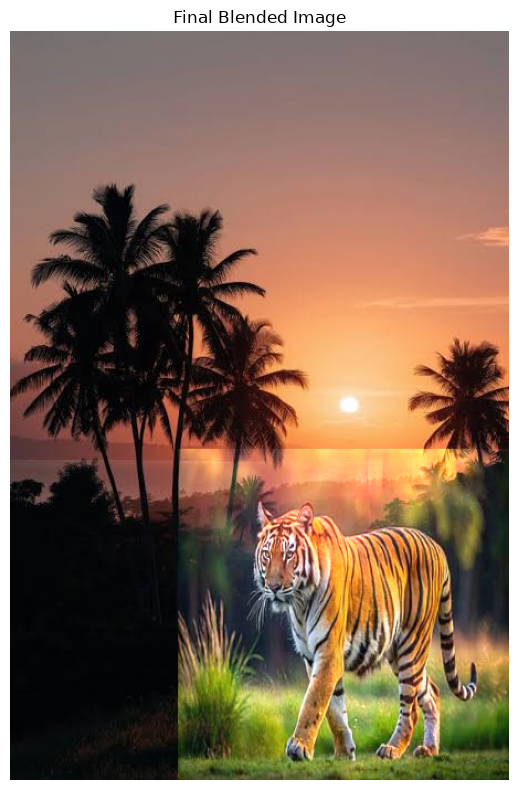


✓ Image blending complete!


In [77]:
# ============================================================================
# CONFIGURATION: Set these parameters for your image blending
# ============================================================================

# Image paths (relative to notebook location)
BACKGROUND_IMAGE_PATH = '../data/images/image1.png'  # Large background image
FOREGROUND_IMAGE_PATH = '../data/images/image3.png'  # Small image to overlay

# Overlay position (in pixels)
Y_OFFSET = 678 - 300  # Vertical position (from top)
X_OFFSET = 452 - 300  # Horizontal position (from left)

# Display settings
FIGURE_SIZE = (12, 8)  # Width x Height in inches

# ============================================================================
# Run blending
# ============================================================================

blended_result = blend_and_display(
    bg_path=BACKGROUND_IMAGE_PATH,
    fg_path=FOREGROUND_IMAGE_PATH,
    y_offset=Y_OFFSET,
    x_offset=X_OFFSET,
    figsize=FIGURE_SIZE
)

print("\n✓ Image blending complete!")